Data Loaded Successfully
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

✅ Categorical Columns Encoded:
Sex: ['F', 'M']
ChestPainType: ['ASY', 'ATA', 'NAP', 'TA']
RestingECG: ['LVH', 'Normal', 'ST']
ExerciseAngina: ['N', 'Y']
ST_Slope: ['Down', 'Flat', '

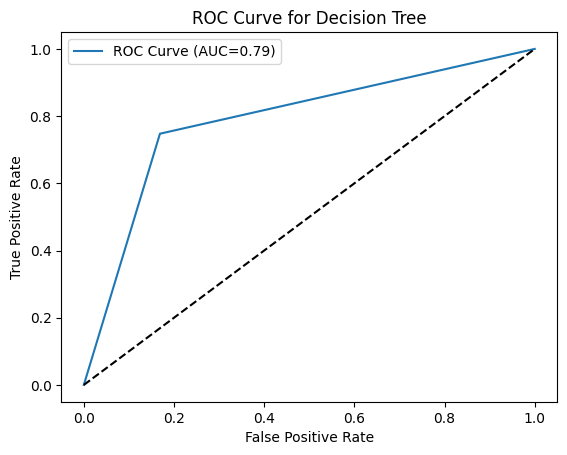


 Model Evaluation (After Pruning):
Accuracy : 0.875
Precision: 0.8962264150943396
Recall   : 0.8878504672897196
F1-Score : 0.892018779342723


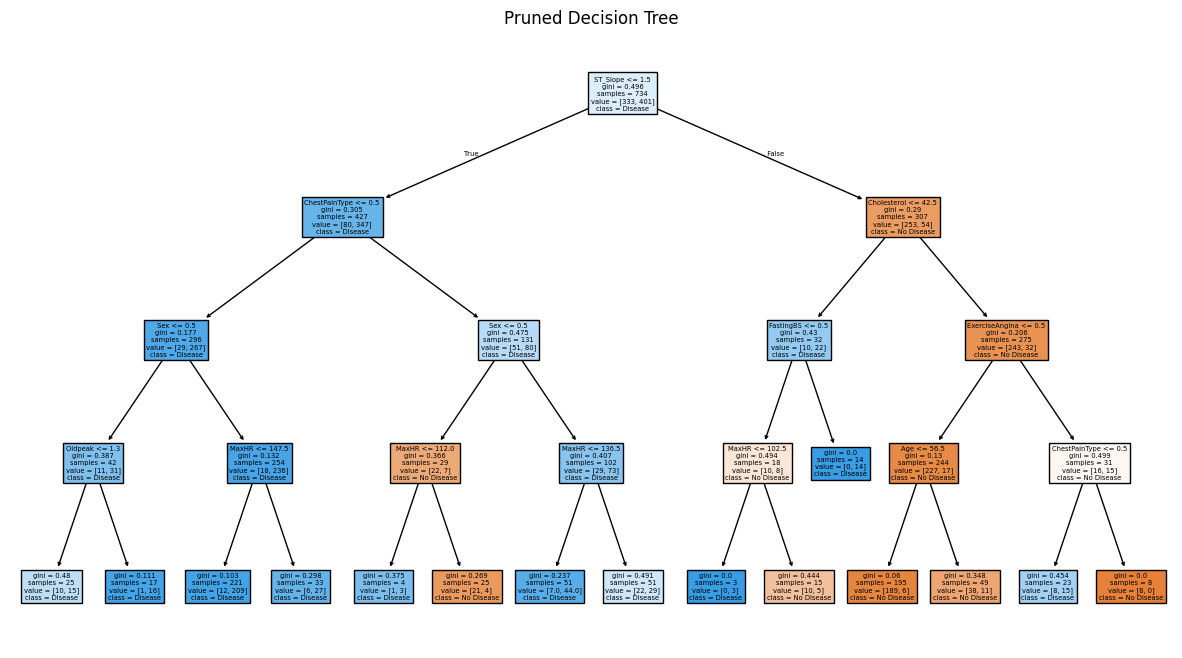

In [ ]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

# Step 2: Load Data
data = pd.read_csv("data/heart.csv")
print("Data Loaded Successfully")
print(data.head())

# Step 3: Encode Categorical Columns
cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
encoder_class = {}

le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])
    encoder_class[col] = le.classes_

print("\n✅ Categorical Columns Encoded:")
for col, classes in encoder_class.items():
    print(f"{col}: {list(classes)}")
print("\n✅ After Encoding:")
print(data.head())

# Step 4: Split Data into Features & Target
X = data.drop("HeartDisease", axis=1)
y = data["HeartDisease"]

# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 6: Create and Train Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 7: Predictions
y_pred = model.predict(X_test)

# Step 8: Evaluation Metrics
print("\n🎯 Model Evaluation (Before Pruning):")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-Score :", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC  :", roc_auc)

# Step 9: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"ROC Curve (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Curve for Decision Tree")
plt.show()

# Step 10: Pruned Decision Tree
pruned_model = DecisionTreeClassifier(criterion='entropy', max_depth=4, min_samples_leaf=3, random_state=42)
pruned_model.fit(X_train, y_train)
y_pred_pruned = pruned_model.predict(X_test)

print("\n Model Evaluation (After Pruning):")
print("Accuracy :", accuracy_score(y_test, y_pred_pruned))
print("Precision:", precision_score(y_test, y_pred_pruned))
print("Recall   :", recall_score(y_test, y_pred_pruned))
print("F1-Score :", f1_score(y_test, y_pred_pruned))

# Step 11: Visualize Pruned Tree
plt.figure(figsize=(15,8))
plot_tree(pruned_model, filled=True, feature_names=X.columns, class_names=["No Disease", "Disease"])
plt.title("Pruned Decision Tree")
plt.show()


Dataset Shape: (918, 12)

First few rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  


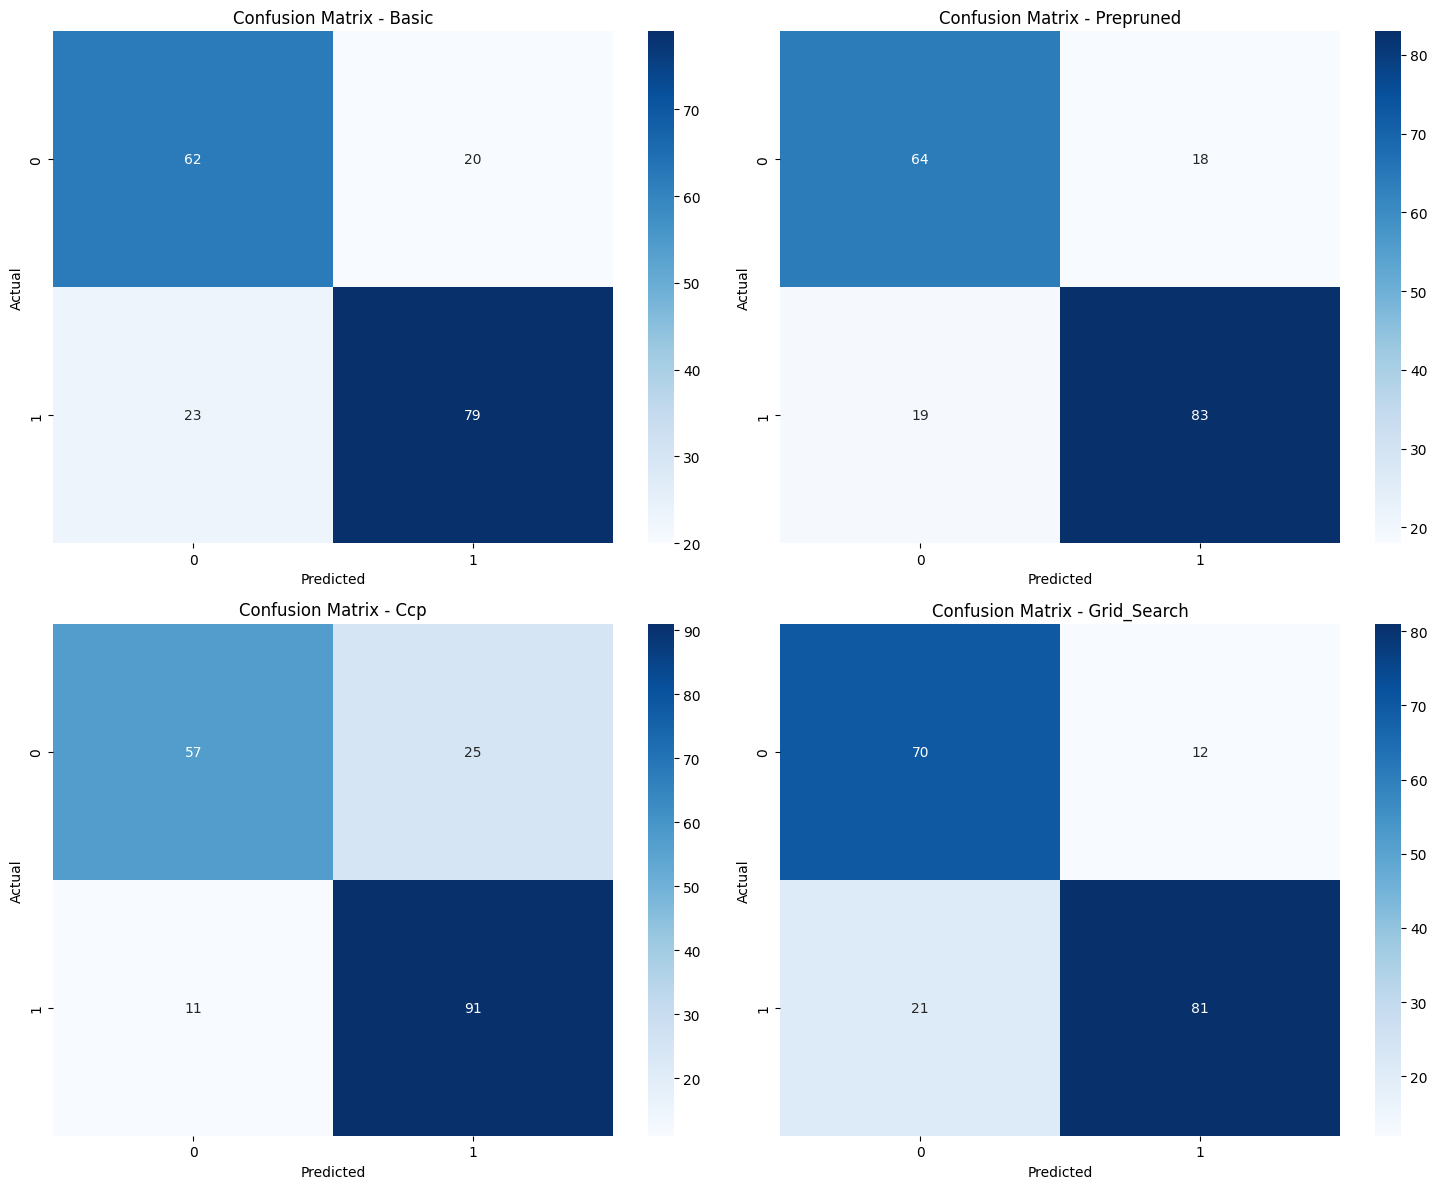

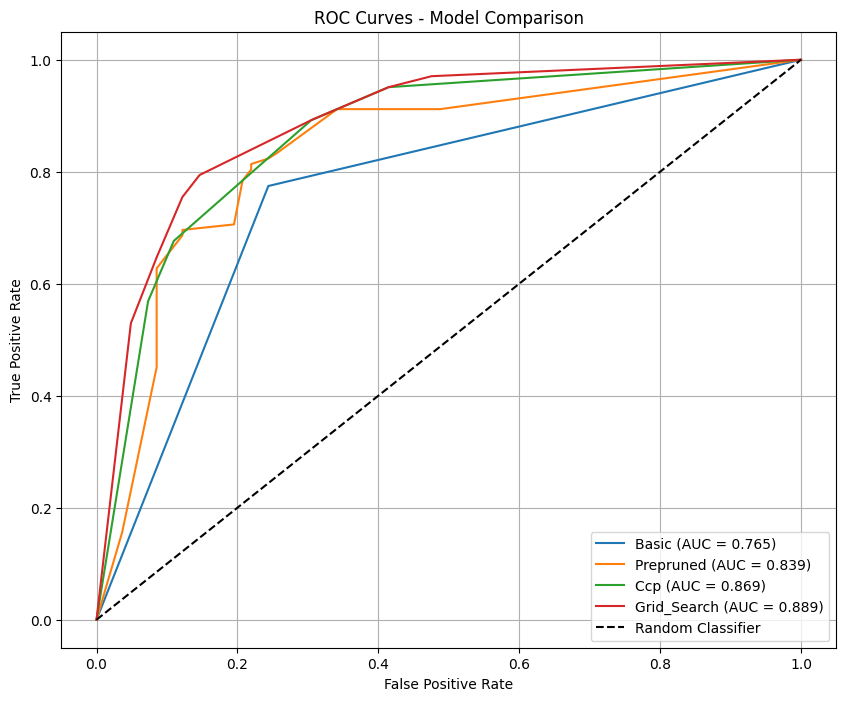

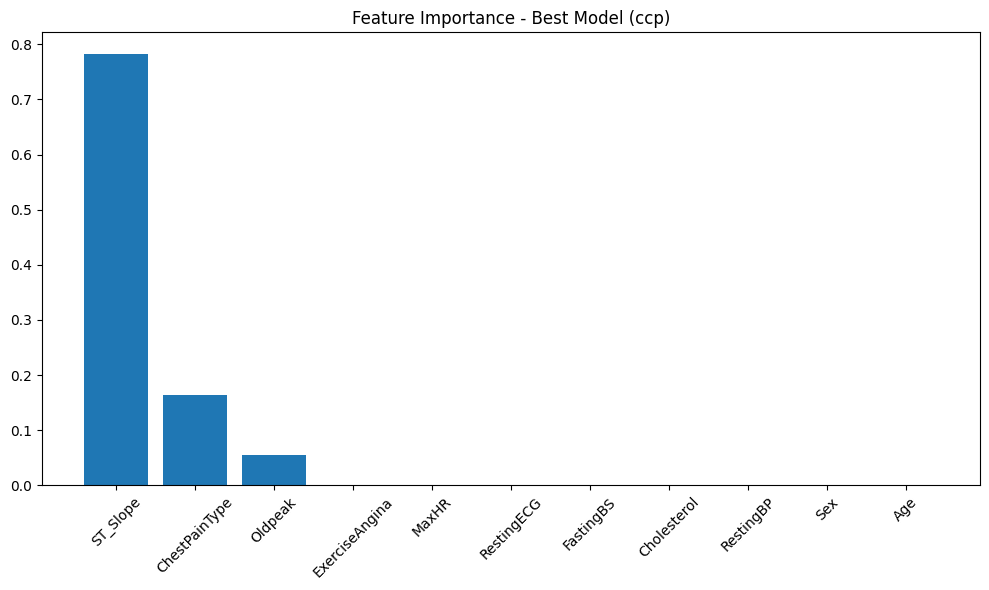

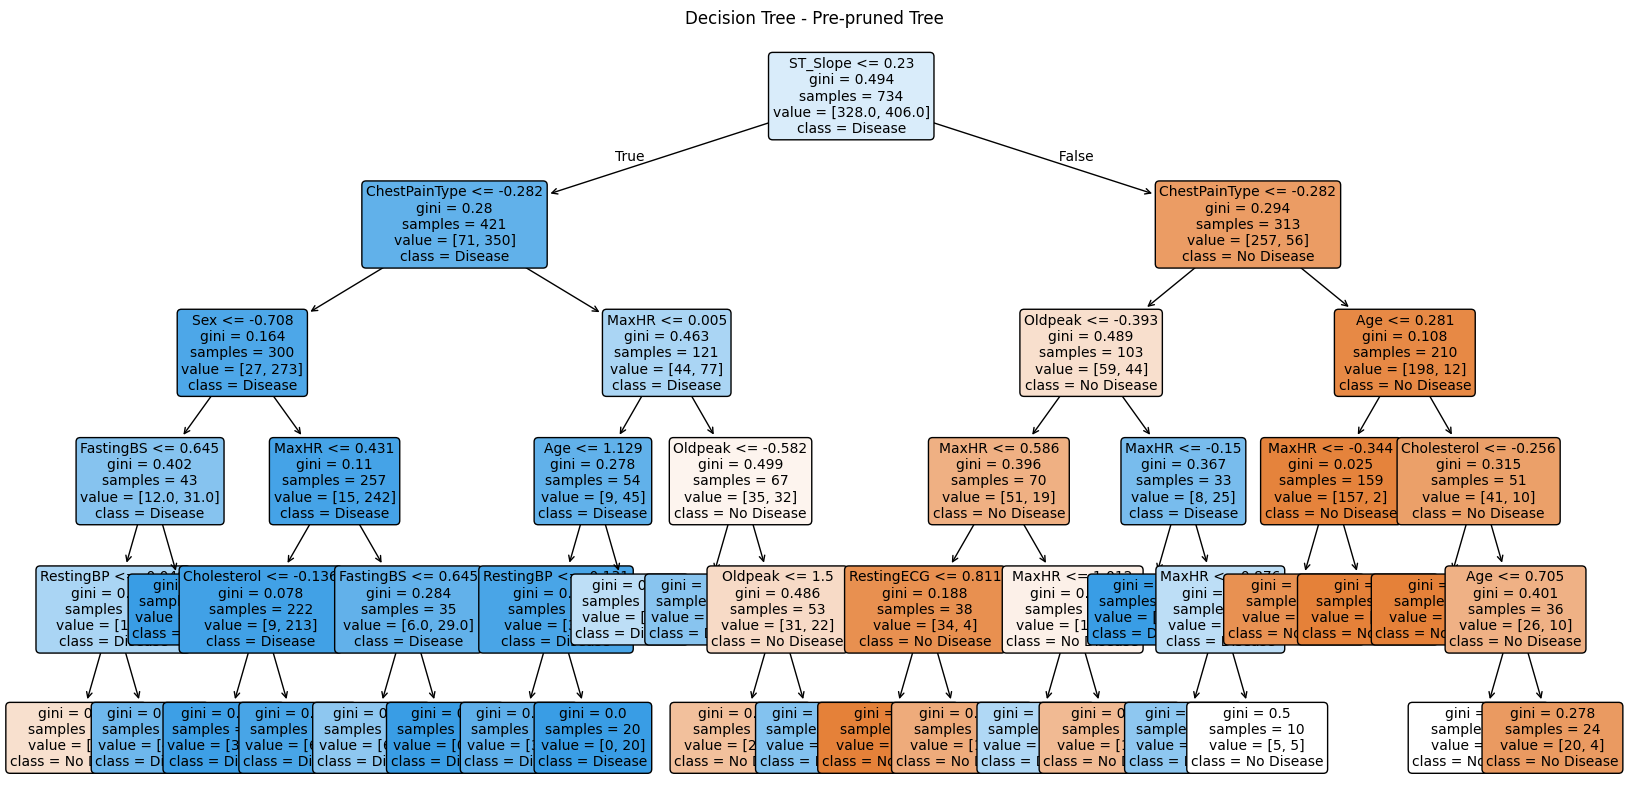


Detailed Classification Report for Best Model (ccp):
              precision    recall  f1-score   support

  No Disease       0.84      0.70      0.76        82
     Disease       0.78      0.89      0.83       102

    accuracy                           0.80       184
   macro avg       0.81      0.79      0.80       184
weighted avg       0.81      0.80      0.80       184


Model Complexities (Number of Nodes):
basic: Nodes = 221, Depth = 13
prepruned: Nodes = 49, Depth = 5
ccp: Nodes = 9, Depth = 3
grid_search: Nodes = 15, Depth = 3


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, roc_auc_score, 
                           roc_curve, classification_report)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Load and explore the dataset
def load_and_explore_data(file_path):
    """Load the dataset and perform initial exploration"""
    df = pd.read_csv(file_path)
    
    print("Dataset Shape:", df.shape)
    print("\nFirst few rows:")
    print(df.head())
    
    print("\nDataset Info:")
    print(df.info())
    
    print("\nStatistical Summary:")
    print(df.describe())
    
    print("\nMissing Values:")
    print(df.isnull().sum())
    
    print("\nHeart Disease Distribution:")
    print(df['HeartDisease'].value_counts())
    
    return df

# Preprocess the data
def preprocess_data(df):
    """Preprocess the data for machine learning"""
    df_processed = df.copy()
    
    # Handle categorical variables
    categorical_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
    label_encoders = {}
    
    for col in categorical_columns:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col])
        label_encoders[col] = le
    
    # Handle missing values (if any)
    numerical_columns = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
    
    # Check for zeros in numerical columns that shouldn't be zero
    for col in ['RestingBP', 'Cholesterol', 'MaxHR']:
        zero_count = (df_processed[col] == 0).sum()
        if zero_count > 0:
            print(f"Warning: {zero_count} zero values in {col}")
    
    # Replace zeros with NaN for appropriate columns
    df_processed['Cholesterol'] = df_processed['Cholesterol'].replace(0, np.nan)
    df_processed['RestingBP'] = df_processed['RestingBP'].replace(0, np.nan)
    
    # Impute missing values
    numerical_imputer = SimpleImputer(strategy='median')
    df_processed[numerical_columns] = numerical_imputer.fit_transform(df_processed[numerical_columns])
    
    return df_processed, label_encoders

# Build and evaluate decision tree model
def build_decision_tree_model(X_train, X_test, y_train, y_test, pruning_method='ccp'):
    """Build decision tree models with different pruning techniques"""
    
    models = {}
    
    # 1. Basic Decision Tree (No Pruning)
    print("Building Basic Decision Tree...")
    dt_basic = DecisionTreeClassifier(random_state=42)
    dt_basic.fit(X_train, y_train)
    models['basic'] = dt_basic
    
    # 2. Pre-pruning with max_depth
    print("Building Pre-pruned Tree (max_depth)...")
    dt_prepruned = DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    )
    dt_prepruned.fit(X_train, y_train)
    models['prepruned'] = dt_prepruned
    
    # 3. Cost Complexity Pruning (Post-pruning)
    print("Building Cost Complexity Pruned Tree...")
    dt_ccp = DecisionTreeClassifier(random_state=42)
    path = dt_ccp.cost_complexity_pruning_path(X_train, y_train)
    ccp_alphas = path.ccp_alphas
    
    # Find optimal alpha using cross-validation
    best_alpha = 0.01  # Default value
    if len(ccp_alphas) > 1:
        cv_scores = []
        for alpha in ccp_alphas:
            if alpha >= 0:
                dt_temp = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
                scores = cross_val_score(dt_temp, X_train, y_train, cv=5)
                cv_scores.append(scores.mean())
        
        if cv_scores:
            best_alpha = ccp_alphas[np.argmax(cv_scores)]
    
    dt_ccp = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
    dt_ccp.fit(X_train, y_train)
    models['ccp'] = dt_ccp
    
    # 4. Grid Search for optimal parameters
    print("Performing Grid Search...")
    param_grid = {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf': [1, 2, 5, 10],
        'criterion': ['gini', 'entropy']
    }
    
    dt_grid = DecisionTreeClassifier(random_state=42)
    grid_search = GridSearchCV(dt_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    models['grid_search'] = grid_search.best_estimator_
    
    print(f"Best parameters from Grid Search: {grid_search.best_params_}")
    
    return models

# Evaluate models
def evaluate_models(models, X_train, X_test, y_train, y_test):
    """Evaluate all models and return metrics"""
    
    results = {}
    
    for name, model in models.items():
        # Predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        auc_roc = roc_auc_score(y_test, y_pred_proba)
        
        # Store results
        results[name] = {
            'model': model,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'auc_roc': auc_roc,
            'predictions': y_pred,
            'probabilities': y_pred_proba,
            'confusion_matrix': confusion_matrix(y_test, y_pred)
        }
        
        print(f"\n{name.upper()} Model Results:")
        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(f"ROC-AUC: {auc_roc:.4f}")
    
    return results

# Visualization functions
def plot_confusion_matrices(results, y_test):
    """Plot confusion matrices for all models"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.ravel()
    
    for idx, (name, result) in enumerate(results.items()):
        cm = result['confusion_matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'Confusion Matrix - {name.title()}')
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('Actual')
    
    plt.tight_layout()
    plt.show()

def plot_roc_curves(results, y_test):
    """Plot ROC curves for all models"""
    plt.figure(figsize=(10, 8))
    
    for name, result in results.items():
        fpr, tpr, _ = roc_curve(y_test, result['probabilities'])
        auc_score = result['auc_roc']
        plt.plot(fpr, tpr, label=f'{name.title()} (AUC = {auc_score:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves - Model Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_feature_importance(model, feature_names, model_name):
    """Plot feature importance for a decision tree model"""
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        indices = np.argsort(importance)[::-1]
        
        plt.figure(figsize=(10, 6))
        plt.title(f'Feature Importance - {model_name}')
        plt.bar(range(len(importance)), importance[indices])
        plt.xticks(range(len(importance)), [feature_names[i] for i in indices], rotation=45)
        plt.tight_layout()
        plt.show()

def plot_decision_tree(model, feature_names, class_names, model_name):
    """Plot the decision tree structure"""
    plt.figure(figsize=(20, 10))
    plot_tree(model, 
              feature_names=feature_names,
              class_names=class_names,
              filled=True,
              rounded=True,
              fontsize=10)
    plt.title(f'Decision Tree - {model_name}')
    plt.show()

# Main execution
def main():
    # Load your dataset
    # Replace 'heart_disease.csv' with your actual file path
    df = load_and_explore_data('data/heart.csv')
    
    # Preprocess the data
    df_processed, label_encoders = preprocess_data(df)
    
    # Prepare features and target
    X = df_processed.drop('HeartDisease', axis=1)
    y = df_processed['HeartDisease']
    feature_names = X.columns.tolist()
    
    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"Training set size: {X_train.shape}")
    print(f"Test set size: {X_test.shape}")
    
    # Scale the features (optional for decision trees, but can help with some implementations)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Build models
    models = build_decision_tree_model(X_train_scaled, X_test_scaled, y_train, y_test)
    
    # Evaluate models
    results = evaluate_models(models, X_train_scaled, X_test_scaled, y_train, y_test)
    
    # Visualizations
    plot_confusion_matrices(results, y_test)
    plot_roc_curves(results, y_test)
    
    # Plot feature importance for the best model
    best_model_name = max(results.items(), key=lambda x: x[1]['f1_score'])[0]
    best_model = results[best_model_name]['model']
    plot_feature_importance(best_model, feature_names, f'Best Model ({best_model_name})')
    
    # Plot decision tree for pre-pruned model (most interpretable)
    if 'prepruned' in models:
        plot_decision_tree(models['prepruned'], feature_names, ['No Disease', 'Disease'], 'Pre-pruned Tree')
    
    # Detailed classification report for best model
    best_predictions = results[best_model_name]['predictions']
    print(f"\nDetailed Classification Report for Best Model ({best_model_name}):")
    print(classification_report(y_test, best_predictions, target_names=['No Disease', 'Disease']))
    
    # Compare model complexities
    print("\nModel Complexities (Number of Nodes):")
    for name, model in models.items():
        n_nodes = model.tree_.node_count if hasattr(model, 'tree_') else 'N/A'
        depth = model.get_depth() if hasattr(model, 'get_depth') else 'N/A'
        print(f"{name}: Nodes = {n_nodes}, Depth = {depth}")

if __name__ == "__main__":
    main()